In [306]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageEnhance
from matplotlib.patches import Arc

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
plt.xkcd();

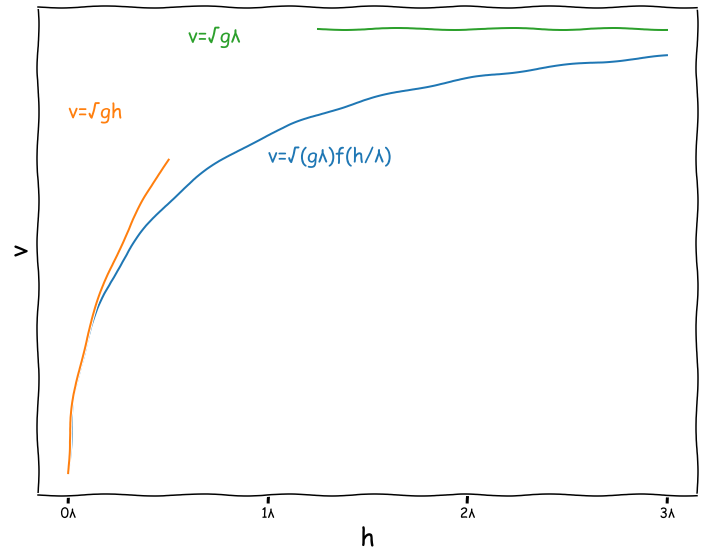

In [43]:
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111)

xs = np.linspace(0, 3, 100)
ys = np.tanh(np.sqrt(xs))
ax.plot(xs, ys)

xs = np.linspace(0, 0.5, 100)
ys = np.sqrt(xs)
ax.plot(xs, ys)

xs = np.linspace(1.25, 3, 100)
ys = xs * 0 + 1
ax.plot(xs, ys)

ax.set_xlabel(r'h', fontsize=25)
ax.set_ylabel(r'v', fontsize=25)

ax.text(1, 0.7, r'v=√(gλ)f(h/λ)', fontsize=20, color=colors[0])
ax.text(0, 0.8, r'v=√gh', fontsize=20, color=colors[1])
ax.text(0.6, 0.97, r'v=√gλ', fontsize=20, color=colors[2])
ax.set_yticks([]);
ax.set_xticks([0, 1, 2, 3]);
ax.set_xticklabels(['0λ', '1λ', '2λ', '3λ']);

plt.tight_layout()
plt.savefig('velocity_vs_h.png')

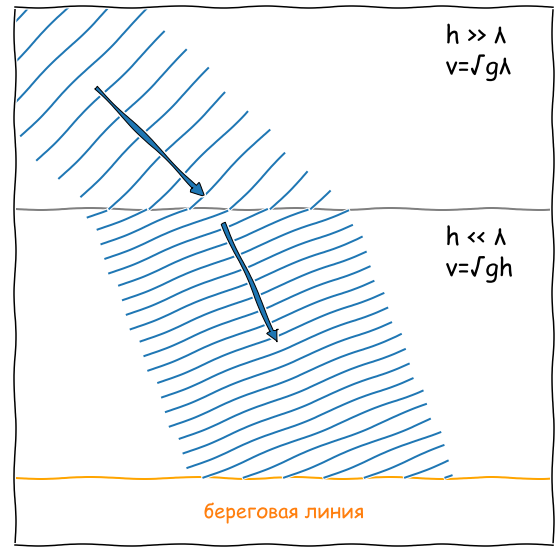

In [150]:
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111)

division = 2.5

coeff = 2.5

disp1 = 5
disp2 = 3

disp3 = division + coeff * (-2.5 + disp1)
disp4 = division + coeff * (-2.5 + disp2)

xs = np.linspace(0, 4, 100)
ys = xs * 0 + division
ax.plot(xs, ys, c='gray')
ys = xs * 0 + 0.5
ax.plot(xs, ys, c='orange')

for i in range(100):
  xs = np.linspace(-5, 4, 200) + i * 0.3
  ys = xs - xs[0] + 2.5
  mask = ((xs < -ys + disp1) & (xs > -ys + disp2))
  ax.plot(xs[mask], ys[mask], c=colors[0])

for i in range(100):
  xs = np.linspace(-5, 4, 200) + i * 0.3 - 0.2
  ys = 1.0/coeff * (xs - xs[0]) + 0.5
  mask = (ys < 2.5) & (ys < -coeff * xs + disp3) & (ys > -coeff * xs + disp4)
  ax.plot(xs[mask], ys[mask], c=colors[0])


ax.set_aspect(1)
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

# xs = np.linspace(0, 3, 100)
# ys = np.tanh(np.sqrt(xs))
# ax.plot(xs, ys)

# xs = np.linspace(0, 0.5, 100)
# ys = np.sqrt(xs)
# ax.plot(xs, ys)

# xs = np.linspace(1.25, 3, 100)
# ys = xs * 0 + 1
# ax.plot(xs, ys)

# ax.set_xlabel(r'h', fontsize=25)
# ax.set_ylabel(r'v', fontsize=25)

# ax.text(1, 0.7, r'v=√(gλ)f(h/λ)', fontsize=20, color=colors[0])
# ax.text(0, 0.8, r'v=√gh', fontsize=20, color=colors[1])
# ax.text(0.6, 0.97, r'v=√gλ', fontsize=20, color=colors[2])
# ax.set_yticks([]);
# ax.set_xticks([0, 1, 2, 3]);
# ax.set_xticklabels(['0λ', '1λ', '2λ', '3λ']);

ax.text(3.2, 3.5, 'h >> λ\nv=√gλ', fontsize=25)
ax.text(3.2, 2., 'h << λ\nv=√gh', fontsize=25)

ax.text(2, 0.2, 'береговая линия', fontsize=20, ha='center', c=colors[1])

ax.annotate('', xy=(1.5, 2.5), xytext=(0.5, 3.5), arrowprops=dict(facecolor=colors[0], shrink=0.1))
ax.annotate('', xy=(2, 1.4), xytext=(1.5, 2.5), arrowprops=dict(facecolor=colors[0], shrink=0.1))

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig('wave_refraction.png')

In [164]:
img = Image.open('ship.png')
img = ImageEnhance.Brightness(img)

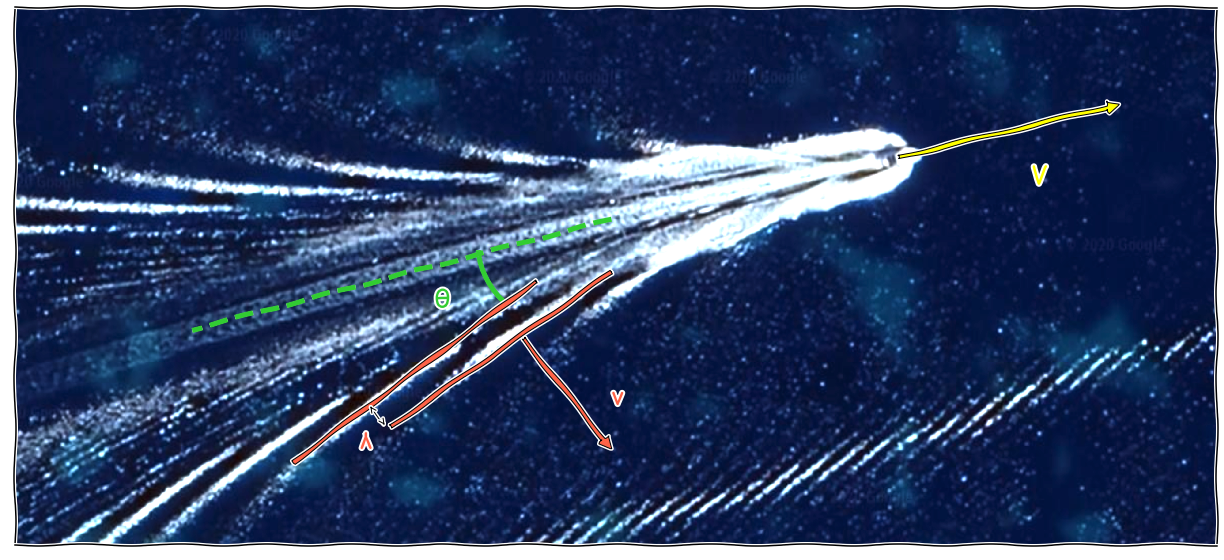

In [343]:
fig = plt.figure(figsize=(20, 8))
ax = plt.subplot(111)

ax.imshow(img.enhance(1.5))
ax.annotate('', xy=(2500, 220), xytext=(2000, 340), arrowprops=dict(facecolor='yellow'))

ax.text(2300, 400, 'V', color='yellow', fontsize=25)
ax.text(1350, 900, 'v', color='tomato', fontsize=25)

ax.annotate('', xy=(1350, 1000), xytext=(1150, 750), arrowprops=dict(facecolor='tomato'))
ax.annotate('', xy=(1350, 600), xytext=(850, 950), arrowprops=dict(facecolor='tomato', headwidth=0.1, headlength=0.1))
ax.annotate('', xy=(1180, 620), xytext=(630, 1030), arrowprops=dict(facecolor='tomato', headwidth=0.1, headlength=0.1))

ax.annotate('', xy=(840, 950), xytext=(800, 900), arrowprops=dict(arrowstyle='<->', facecolor='tomato'))

ax.plot([1350, 400], [480, 730], c='limegreen', ls='--', lw=5)

ax.add_patch(Arc([1200, 550], 300, 300, 45, theta1=80, theta2=135, lw=5, color='limegreen'))
ax.text(950, 680, 'θ', color='limegreen', fontsize=25)

ax.text(780, 1000, 'λ', color='tomato', fontsize=25)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

# plt.savefig('ship_wake.png')

In [342]:
v1 = np.array([400, 730]) - np.array([1350, 480])
v2 = np.array([630, 1030]) - np.array([1180, 620])

def theta(v, w): return np.arccos(v.dot(w) / (np.linalg.norm(v) * np.linalg.norm(w)))

theta(v1, v2) * 180 / np.pi

21.95929219369238